![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [36]:
import warnings
warnings.filterwarnings('ignore')

In [37]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, f1_score
import numpy as np
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

pd.options.display.max_columns = 1000

In [38]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [39]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [40]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [41]:
bikes.groupby('season').total.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [42]:
bikes.groupby('season').atemp.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,15.228956,6.092218,0.760,10.605,14.395,20.455,32.575
2,2733.0,26.647098,5.491321,11.365,22.725,26.515,31.060,43.940
3,2733.0,32.540783,4.594888,12.120,30.305,33.335,35.605,45.455
4,2734.0,20.059909,5.264197,7.575,15.910,20.455,24.240,34.090


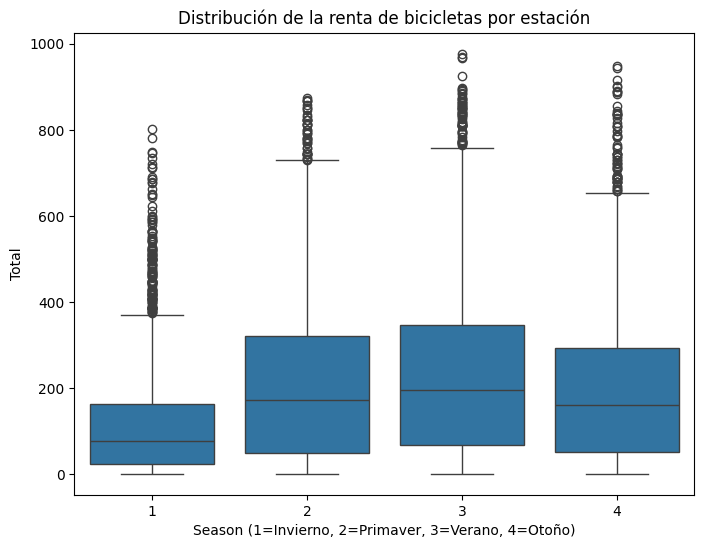

In [43]:
plt.figure(figsize=(8,6))
sns.boxplot(x='season', y='total', data=bikes)

plt.title('Distribución de la renta de bicicletas por estación')
plt.xlabel('Season (1=Invierno, 2=Primaver, 3=Verano, 4=Otoño)')
plt.ylabel('Total')

plt.show()

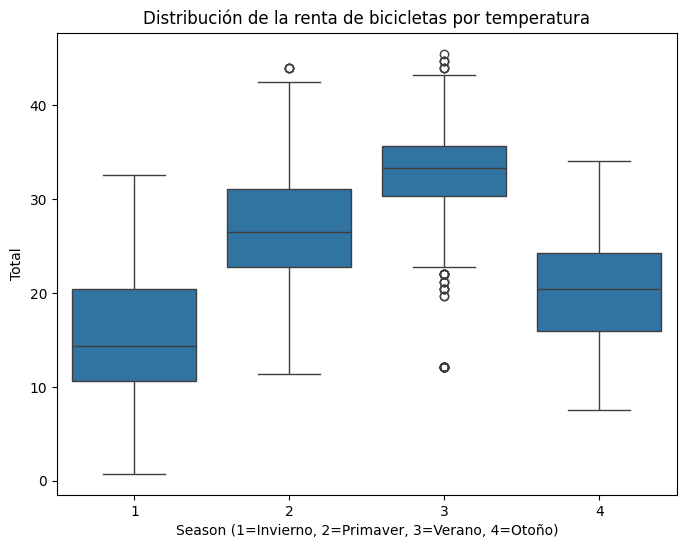

In [44]:
plt.figure(figsize=(8,6))
sns.boxplot(x='season', y='atemp', data=bikes)

plt.title('Distribución de la renta de bicicletas por temperatura')
plt.xlabel('Season (1=Invierno, 2=Primaver, 3=Verano, 4=Otoño)')
plt.ylabel('Total')

plt.show()

La temperatura explica el patrón de demanda: en invierno **(season 1)** la temperatura sensible promedio es de apenas `15.2` °C (con mínimos de `0.76` °C), lo que desincentiva el uso de bicicletas — su media de rentas (`116`) es un `51%` menor que en verano (`234`). En verano, con temperaturas medias de `32.5` °C y máximas de hasta `45.5` °C, el alquiler alcanza su pico máximo registrado de `977` unidades por hora. El otoño cae a `199` a medida que las temperaturas descienden desde el pico, lo que confirma la correlación positiva entre temperatura y demanda. 
Esto tambien se puede evidenciar en los diagramas box plot en donde a menores temperaturas menor es el rango intercuartil de la renta de bicicletas, mientras a mayor temperatura mayor valor es alcanzado en renta de bicicletas en el quartil tres, como es el caso de primavera y verano.  

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

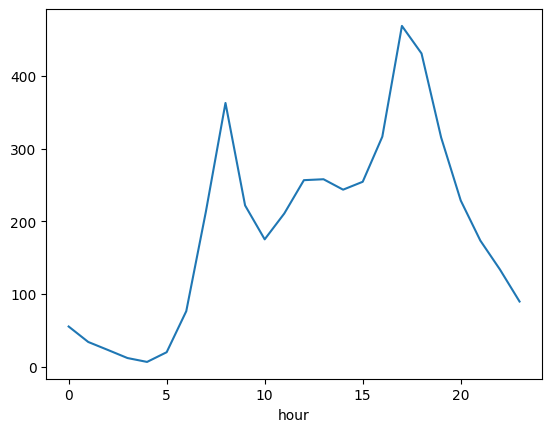

In [45]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

El patrón horario refleja claramente los desplazamientos laborales: dos picos, uno a las 8:00 AM (`363` rentas/hora en promedio) y a las `5:00` PM (`469` rentas/hora), y dos valles: el más profundo a las 4:00 AM (`6.4` rentas/hora) y una caída a partir de las 20:00 h. Este comportamiento bimodal es un comportamiente frecuente de las ciudades capitales, regido por horas pico y valle. 

<Axes: xlabel='hour'>

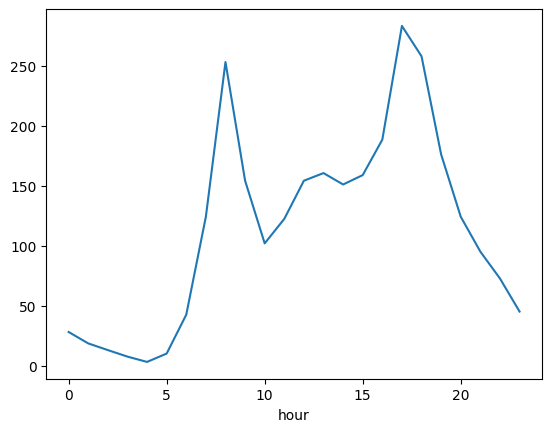

In [46]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot()

Misma distribución bimodal, pero con amplitudes menores. El pico en horas de la tarde `(17 h)` alcanza `283` rentas/hora — un 40% menos que el promedio general `(468)` y `253` rentas/hora en la maxima hora pico de la mañana `(8 h)`. El frío y las condiciones climáticas adversas tienen un impacto negativo sobre la demanda durante todo el día.

<Axes: xlabel='hour'>

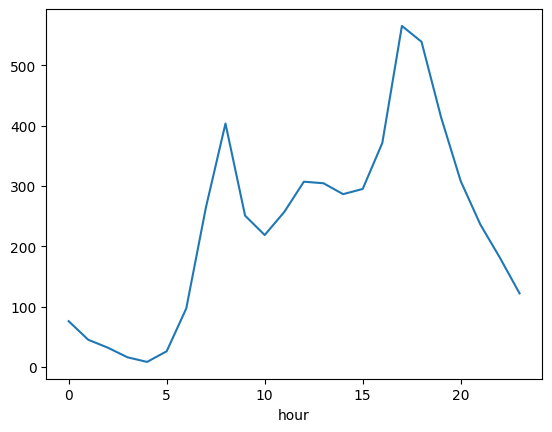

In [47]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot()

Los picos de verano superan los `400` (8 h) y `565` rentas/hora (17 h) respectivamente — más del doble que en invierno. El patrón horario se mantiene idéntico, pero la escala es significativamente mayor: la temperatura amplifica la demanda sin cambiar su comportamiento o forma.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [48]:
# Funcion para evaluar los modelos
def evaluar_modelos(models, X_train, y_train, X_test, y_test):

    for name, model in models.items():
        model.fit(X_train, y_train)

    
    y_pred_df = pd.DataFrame(index=X_test.index)

    for name, model in models.items():
        y_pred_df[name] = model.predict(X_test)

    
    metrics = {}

    for name in models.keys():
        mse = mean_squared_error(y_test, y_pred_df[name])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred_df[name])
        r2 = r2_score(y_test, y_pred_df[name])

        metrics[name] = {
            'RMSE': rmse,
            'MSE': mse,
            'MAE': mae,
            'R2': r2
        }

        print(f"MODELO: {name.upper()} ")
        print(f"MSE :  {mse:.4f}")
        print(f"RMSE:  {rmse:.4f}")
        print(f"MAE :  {mae:.4f}")
        print(f"R2   :  {r2:.4f}")
        print()

    return y_pred_df, metrics

In [49]:
# Transformacion de variables categoricas a hot-encoding
season_map = {
    1: "winter",
    2: "spring",
    3: "summer",
    4: "fall"
}

bikes["season_name"] = bikes["season"].map(season_map)

bikes = pd.get_dummies(bikes, columns=["season_name"], prefix="season")

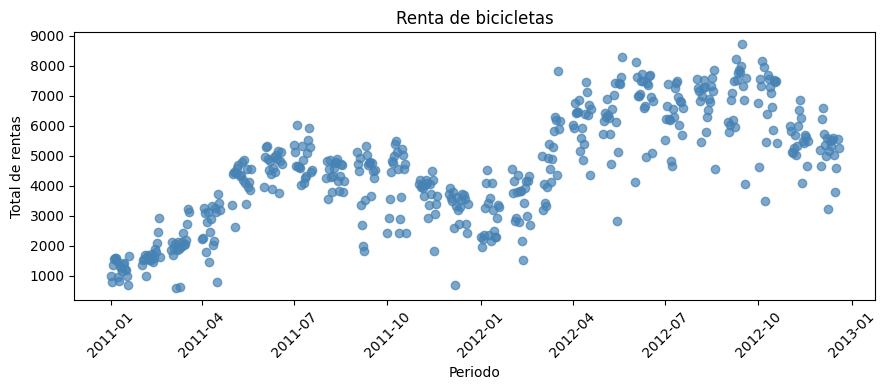

In [50]:
df_time = bikes.groupby(bikes.index.date)['total'].sum()

plt.figure(figsize=(9,4))
plt.scatter(df_time.index, df_time.values, color='steelblue', alpha=0.7)

plt.title('Renta de bicicletas')
plt.xlabel('Periodo')
plt.ylabel('Total de rentas')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# Celda 3
new_data_set = bikes[['season','season_fall', 'season_spring', 'season_summer', 'season_winter', 'hour', 'total']] 
train = new_data_set.loc['2011-01-01':'2011-12-31', ['season_fall', 'season_spring', 'season_summer', 'season_winter', 'hour', 'total']]
test = new_data_set.loc['2012-01-01':'2013-12-31', ['season_fall', 'season_spring', 'season_summer', 'season_winter', 'hour', 'total']]

    # Training sets
X_train = train[['season_fall', 'season_spring', 'season_summer', 'season_winter', 'hour']]
y_train = train['total']

    # Test sets
X_test = test[['season_fall', 'season_spring', 'season_summer', 'season_winter', 'hour']]
y_test = test['total']


models = {
    'regresion lineal': LinearRegression(),

}

y_pred, metrics = evaluar_modelos(models, X_train, y_train, X_test, y_test)

MODELO: REGRESION LINEAL 
MSE :  43194.1411
RMSE:  207.8320
MAE :  146.2276
R2   :  0.0025



In [52]:
lr_model = models['regresion lineal']

coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lr_model.coef_
}).sort_values('Coeficiente', ascending=False)

print(coef_df.to_string(index=False))

     Variable  Coeficiente
season_summer    43.750282
season_spring    17.813347
  season_fall    11.659726
         hour     7.993238
season_winter   -73.223355


Detalle de los coeficientes y limitaciones del modelo:

1. Coeficientes

    - **Verano** añade en promedio `43.75` rentas por hora. Es el coeficiente positivo más grande entre las estaciones, lo que confirma que el verano es la estación de mayor demanda, consistente con las temperaturas más altas `(media 32.5 °C)` que favorecen el uso de bicicletas.

    - La **primavera** añade `17.81` rentas por hora adicionales. Es la segunda estación más favorable, coherente con temperaturas agradables `(media 26.6 °C)` y buenas condiciones climáticas.

    - El **otoño** suma `11.66` rentas por hora. Su efecto positivo pero moderado refleja el descenso gradual de temperatura desde el verano `(media 20.1 °C)`, que reduce la demanda aunque sin llegar a los niveles del invierno.


    - Por cada **hora** adicional del día, el modelo predice `7.99` rentas más. Por ejemplo, de las `8 AM` a las `9 AM` se esperan `8` rentas adicionales. Sin embargo, este coeficiente tiene una limitación. Este asume que la relación entre hora y demanda es lineal y creciente, cuando en realidad la demanda es bimodal (picos a las 8h y 17 h o valle a las 4 AM). La regresión lineal no puede capturar este comportamiento.

    - El **invierno** resta `73.22` rentas por hora, siendo el mayor efecto individual en el modelo  y el único negativo.  El modelo aprende que el invierno suprime fuertemente la demanda respecto a ese punto, lo que coincide con las temperaturas más bajas del dataset `(mínimo 0.8 °C)`. Este coeficiente negativo de gran magnitud explica por qué la media de esta estación `(116 rentas/h)` es tan inferior a la de verano `(234 rentas/h)`.

2. Limitaciones del modelo lineal

    - Interpretacion lineal de un comportamiento no lineal: la relación entre hora y rentas es bimodal (dos picos a las `8h` y a las `17h`), algo que la línea recta de la regresión no puede modelar. El R² de `0.0025` (casi cero) confirma que el modelo no explica prácticamente ninguna varianza.
    - Interacciones no modeladas: el efecto de la hora depende de la estación (un pico de 565 en verano vs 283 en invierno). La regresión lineal suma efectos independientes sin capturar esas interacciones.



### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [53]:
def variance(y):
    if len(y) == 0:
        return 0
    return np.var(y)

def variance_reduction(X_col, y, split):
    
    left = y[X_col < split]
    right = y[X_col >= split]
    
    n = len(y)
    n_l = len(left)
    n_r = len(right)
    
    if n_l == 0 or n_r == 0:
        return 0
    
    var_total = variance(y)
    var_l = variance(left)
    var_r = variance(right)
    
    reduction = var_total - (n_l/n)*var_l - (n_r/n)*var_r
    
    return reduction

def best_split(X, y, num_pct=10):
    
    best = [0, 0, -np.inf]  # feature, split, gain
    
    for j in range(X.shape[1]):
        
        splits = np.percentile(X.iloc[:, j], np.linspace(0, 100, num_pct))
        splits = np.unique(splits)
        
        for split in splits:
            gain = variance_reduction(X.iloc[:, j], y, split)
            
            if gain > best[2]:
                best = [j, split, gain]
    
    return best

def tree_grow(X, y, depth=0, max_depth=3, min_samples=50):
    
    
    if len(y) <= min_samples or depth >= max_depth:
        return {"prediction": y.mean()}
    
    j, split, gain = best_split(X, y)
    
    if gain <= 0:
        return {"prediction": y.mean()}
    
    left_mask = X.iloc[:, j] < split
    
    left_tree = tree_grow(X[left_mask], y[left_mask], depth+1, max_depth)
    right_tree = tree_grow(X[~left_mask], y[~left_mask], depth+1, max_depth)
    
    return {
        "feature": j,
        "split": split,
        "left": left_tree,
        "right": right_tree
    }

def tree_predict(X, tree):
    
    preds = []
    
    for i in range(len(X)):
        node = tree
        
        while "prediction" not in node:
            j = node["feature"]
            split = node["split"]
            
            if X.iloc[i, j] < split:
                node = node["left"]
            else:
                node = node["right"]
        
        preds.append(node["prediction"])
    
    return np.array(preds)


In [54]:
train = new_data_set.loc['2011-01-01':'2011-12-31', ['season', 'hour', 'total']]
test = new_data_set.loc['2012-01-01':'2013-12-31', ['season', 'hour', 'total']]

    # Training sets
X_train = train[['season', 'hour']]
y_train = train['total']

    # Test sets
X_test = test[['season', 'hour']]
y_test = test['total']

In [ ]:
tree = tree_grow(X_train, y_train, max_depth=3)

preds = tree_predict(X_test, tree)

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 32789.32735702308
RMSE: 181.07823545921548
MAE: 117.98904592211667
R2: 0.2428021169478477


In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

def plot_tree(tree, feature_names=None):

    G = nx.DiGraph()
    node_labels = {}
    node_colors = {}
    edge_labels = {}
    counter = [0]

    def build_graph(node, parent=None, branch_label=None):
        node_id = counter[0]
        counter[0] += 1

        if "prediction" in node:
            label = f"Pred:\n{node['prediction']:.3f}"
            node_colors[node_id] = "#1D9E75"  # verde para hojas
        else:
            feat = node["feature"]
            name = feature_names[feat] if feature_names else f"X[{feat}]"
            label = f"{name}\n< {node['split']:.3f}"
            node_colors[node_id] = "#3B8BD4"  # azul para nodos internos

        G.add_node(node_id)
        node_labels[node_id] = label

        if parent is not None:
            G.add_edge(parent, node_id)
            edge_labels[(parent, node_id)] = branch_label

        if "left" in node:
            build_graph(node["left"],  parent=node_id, branch_label="False\n(< split)")
        if "right" in node:
            build_graph(node["right"], parent=node_id, branch_label="True\n(≥ split)")

    build_graph(tree)

    # Layout jerárquico
    def hierarchy_pos(G, root=0, width=1.0, vert_gap=0.25, vert_loc=0, xcenter=0.5):
        pos = {}
        def _hierarchy_pos(G, node, left, right, vert_loc, pos):
            pos[node] = ((left + right) / 2, vert_loc)
            children = list(G.successors(node))
            if children:
                dx = (right - left) / len(children)
                for i, child in enumerate(children):
                    _hierarchy_pos(G, child, left + i*dx, left + (i+1)*dx, vert_loc - vert_gap, pos)
        _hierarchy_pos(G, root, 0, width, vert_loc, pos)
        return pos

    pos = hierarchy_pos(G)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#F8F9FA")

    colors = [node_colors[n] for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=colors,
                           node_size=3500,
                           node_shape="s")      # cuadrado

    nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                            font_size=7.5,
                            font_color="white",
                            font_weight="bold")

    # Aristas con colores distintos según True/False
    false_edges = [(u, v) for (u, v), lbl in edge_labels.items() if lbl.startswith("False")]
    true_edges  = [(u, v) for (u, v), lbl in edge_labels.items() if lbl.startswith("True")]

    nx.draw_networkx_edges(G, pos, edgelist=false_edges, ax=ax,
                           edge_color="#E24B4A", arrows=True,
                           arrowstyle="-|>", arrowsize=18,
                           width=2, connectionstyle="arc3,rad=0.0")

    nx.draw_networkx_edges(G, pos, edgelist=true_edges, ax=ax,
                           edge_color="#1D9E75", arrows=True,
                           arrowstyle="-|>", arrowsize=18,
                           width=2, connectionstyle="arc3,rad=0.0")

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=7.5,
                                 font_color="#333333",
                                 bbox=dict(boxstyle="round,pad=0.3",
                                           fc="white", ec="none", alpha=0.85))

    # Leyenda
    legend = [
        mpatches.Patch(color="#3B8BD4", label="Nodo interno (condición)"),
        mpatches.Patch(color="#1D9E75", label="Hoja (predicción)"),
        mpatches.Patch(color="#E24B4A", label="False  (x < umbral)"),
        mpatches.Patch(color="#1D9E75", label="True   (x ≥ umbral)"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=8, framealpha=0.9)

    ax.set_title("Árbol de decisión manual", fontsize=13, pad=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

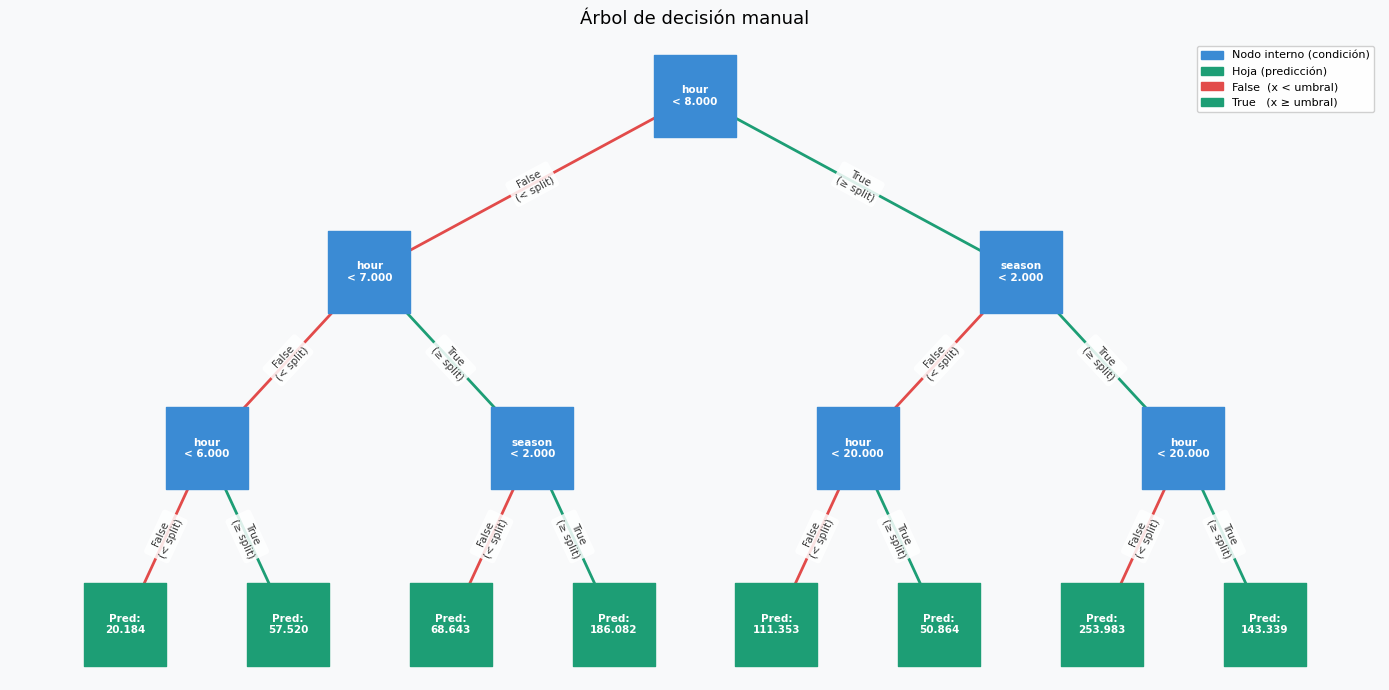

In [57]:
# Ejemplo: supón que tu DataFrame se llama df y la variable objetivo es "target"

tree = tree_grow(X_train, y_train, max_depth=3, min_samples=50)

# Pasa los nombres reales de tus features
plot_tree(tree, feature_names=list(X_train.columns))

 El árbol manual logra un **R2** de `0.243`, explicando el `24.3%` de la varianza de rentas — frente al **R2** = `0.0025` de la regresión lineal. El **RMSE** de `181.1` significa que el error típico de predicción es de `181` bicicletas por hora. En términos del **MAE**, el error absoluto promedio es de `118` rentas/hora: si la demanda real era `362` (pico `8` AM), el árbol podría predecir entre `244` y `480`. El modelo captura la estructura general

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [58]:
# Celda 5
from sklearn.model_selection import cross_val_score

# Iterar sobre distintos valores de max_depth
max_depth_range = range(1, 21)
cv_scores = []

for d in max_depth_range:
    clf = DecisionTreeRegressor(max_depth=d, random_state=1)
    score = cross_val_score(clf, X_train, y_train,
                            cv=5, scoring='neg_root_mean_squared_error').mean()
    cv_scores.append(-score)

# Mejor profundidad
best_depth = max_depth_range[cv_scores.index(min(cv_scores))]
print(f"Mejor max_depth: {best_depth}")

# Entrenar con la mejor profundidad
best_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
best_tree.fit(X_train, y_train)

models = {'Árbol calibrado': best_tree}
y_pred, metrics = evaluar_modelos(models, X_train, y_train, X_test, y_test)

Mejor max_depth: 6
MODELO: ÁRBOL CALIBRADO 
MSE :  27137.6723
RMSE:  164.7352
MAE :  112.1349
R2   :  0.3733



Hay una mejora clara: cada modelo captura mejor la no linealidad del problema. La regresión lineal no puede modelar los picos de demanda **(R² cercano a 0)**. El árbol manual con profundidad 3 ya captura la estructura bimodal. El árbol sklearn, al explorar más puntos de corte y mayor profundidad, refina aún más esas regiones.

El **R2** de `0.373` indica que el árbol calibrado explica el `37.3%` de la varianza — mejora de +13 puntos porcentuales sobre el árbol manual `(0.243)`. El **RMSE** de `164.7` implica un error típico de `165` aprox de bicicletas por hora. Con `depth=6` el árbol tiene suficiente capacidad para capturar la interacción entre hora y estación, que es el patrón clave del dataset.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [59]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,2.0,4.702128,7.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1300.0,259.718000,0.0,843300.0,482257.142857,0.000000,6963.954292,3415.943322,4500.0,4500.0,4500.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.028582,0.028594,0.028578,0.745673,0.168573,0.625376,0.144737,0.053191,0.021277,0.714286,0.285714,0.470000,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,0.0,5.010101,8.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,919.0,250.142857,0.0,843300.0,142712.500000,0.000000,4429.750000,2610.941050,928.0,928.0,928.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.027098,0.025006,0.276713,0.025003,0.646181,0.376439,0.056574,0.030303,0.030303,0.500000,0.500000,0.342778,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,0.0,3.972376,6.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,791.0,205.666667,4800.0,843300.0,229066.666667,2440.825000,3300.698315,2895.516309,1300.0,1300.0,1300.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.033499,0.200063,0.033411,0.033334,0.699693,0.462500,0.535795,0.049724,0.000000,1.000000,0.000000,0.516263,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,0.0,4.467350,7.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1200.0,280.800000,0.0,843300.0,335642.857143,0.000000,4415.722689,2103.971787,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.457963,0.028580,0.456140,0.028627,0.028690,0.425314,0.091016,0.030730,0.023047,0.571429,0.428571,0.436654,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,0.0,5.146893,4.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,935.0,268.250000,1700.0,843300.0,258100.000000,1218.111111,3588.790194,2809.374181,2400.0,8200.0,5300.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.051121,0.050014,0.050167,0.050003,0.798695,0.370238,0.148214,0.039548,0.011299,0.777778,0.222222,0.346429,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [60]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [61]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [62]:
print(np.unique(y_train))

[0 1]


### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [63]:
# Celda 6
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

tree = DecisionTreeClassifier(max_depth=5, random_state=0)
logreg = LogisticRegression(max_iter=1000)

tree.fit(X_train, y_train)
logreg.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
pred_log = logreg.predict(X_test)

print("Arbol de decision")
print("Accuracy:", accuracy_score(y_test, pred_tree))
print("F1-score:", f1_score(y_test, pred_tree))

print("\nRegresion Logistica")
print("Accuracy:", accuracy_score(y_test, pred_log))
print("F1-score:", f1_score(y_test, pred_log))


Arbol de decision
Accuracy: 0.6373333333333333
F1-score: 0.6616915422885572

Regresion Logistica
Accuracy: 0.6153333333333333
F1-score: 0.6039807824296499


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: 

(100 * 55% + 100 * 55%+100 * 10%)/300 = 40% 

de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [64]:
# Celda 7

clf_tree_depth = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=0),
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

clf_tree_depth.fit(X_train, y_train)
pred_tree_depth = clf_tree_depth.predict(X_test)


clf_tree_leaf = BaggingClassifier(
    estimator=DecisionTreeClassifier(min_samples_leaf=20, random_state=0),
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

clf_tree_leaf.fit(X_train, y_train)
pred_tree_leaf = clf_tree_leaf.predict(X_test)


clf_log = BaggingClassifier(
    estimator=LogisticRegression(max_iter=1000),
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

clf_log.fit(X_train, y_train)
pred_log = clf_log.predict(X_test)


print("Arbol de decision (max_depth)")
print("Accuracy:", accuracy_score(y_test, pred_tree_depth))
print("F1-score:", f1_score(y_test, pred_tree_depth))

print("\n Arbol de decision (min_samples_leaf)")
print("Accuracy:", accuracy_score(y_test, pred_tree_leaf))
print("F1-score:", f1_score(y_test, pred_tree_leaf))

print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_log))
print("F1-score:", f1_score(y_test, pred_log))


preds_all = []

# Agregacion de los resultados a la lista preds_all
for model in clf_tree_depth.estimators_:
    preds_all.append(model.predict(X_test))


for model in clf_tree_leaf.estimators_:
    preds_all.append(model.predict(X_test))


for model in clf_log.estimators_:
    preds_all.append(model.predict(X_test))

preds_all = np.array(preds_all) 

# Conteo de la votacion
final_pred = np.apply_along_axis(
    lambda x: np.bincount(x).argmax(),
    axis=0,
    arr=preds_all
)


print("\n Ensamblaje final (300 modelos - Votación Mayoritaria)")
print("Accuracy:", accuracy_score(y_test, final_pred))
print("F1-score:", f1_score(y_test, final_pred))

Arbol de decision (max_depth)
Accuracy: 0.6573333333333333
F1-score: 0.6573333333333333

 Arbol de decision (min_samples_leaf)
Accuracy: 0.654
F1-score: 0.6551495016611296

 Logistic Regression
Accuracy: 0.6146666666666667
F1-score: 0.603021978021978

 Ensamblaje final (300 modelos - Votación Mayoritaria)
Accuracy: 0.6393333333333333
F1-score: 0.6297056810403833


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [65]:
# Celda 8

from sklearn import metrics

preds_all = []
weights = []

# Extraccion de pesos
def get_weights(clf):
    errors = np.zeros(clf.n_estimators)
    preds = np.zeros((X_test.shape[0], clf.n_estimators))
    
    for i in range(clf.n_estimators):
        oob_sample = ~clf.estimators_samples_[i]
        
        y_pred_oob = clf.estimators_[i].predict(X_train.values[oob_sample])
        errors[i] = metrics.accuracy_score(y_train.values[oob_sample], y_pred_oob)
        
        preds[:, i] = clf.estimators_[i].predict(X_test)
    
    alpha = (1 - errors) / (1 - errors).sum()
    
    return preds.T, alpha

preds1, w1 = get_weights(clf_tree_depth)
preds2, w2 = get_weights(clf_tree_leaf)
preds3, w3 = get_weights(clf_log)

# Combinacion de todos
preds_all = np.vstack((preds1, preds2, preds3))
weights_all = np.concatenate((w1, w2, w3))

final_pred_weighted = []

for i in range(preds_all.shape[1]):
    
    votes = {0: 0, 1: 0}
    
    for j in range(preds_all.shape[0]):
        votes[preds_all[j, i]] += weights_all[j]
    
    final_pred_weighted.append(max(votes, key=votes.get))

print("\nEnsamblaje votacion ponderado")
print("Accuracy:", accuracy_score(y_test, final_pred_weighted))
print("F1:", f1_score(y_test, final_pred_weighted))


Ensamblaje votacion ponderado
Accuracy: 0.6393333333333333
F1: 0.6297056810403833


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [66]:
# Celda 9

print("Arbol de decision:", accuracy_score(y_test, pred_tree))
print("Regresion logistica:", accuracy_score(y_test, pred_log))
print("Votacion mayoritaria:", accuracy_score(y_test, final_pred))
print("Votacion ponderada:", accuracy_score(y_test, final_pred_weighted))

Arbol de decision: 0.6373333333333333
Regresion logistica: 0.6146666666666667
Votacion mayoritaria: 0.6393333333333333
Votacion ponderada: 0.6393333333333333


- Los árboles de decisión con bagging superaron a la regresión logística. El árbol con max_depth=5 alcanzó un Accuracy de `0.6573` y F1 de `0.6573`, frente al `0.6147` y `0.6030` de la regresión logística, una diferencia de **4.3** puntos porcentuales en Accuracy. Esto sugiere que la relación entre las variables predictoras y la variable objetivo tiene componentes no lineales que los árboles capturan mejor.
- La votación simple (mayoría) no mejoró el mejor modelo individual. El ensamble de **300** modelos con votación mayoritaria obtuvo un Accuracy de `0.6393`, por debajo del árbol con `max_depth=5` (`0.6573`). Esto puede deberse a que incluir modelos más débiles (como la regresión logística) en el voto deteriora el rendimiento.
- La votación ponderada no aportó ganancia sobre la votación simple. Ambos métodos de votación obtuvieron exactamente los mismos resultados (Accuracy: `0.6393`, F1: `0.6297`). Esto indica que el esquema de ponderación por error OOB no logró discriminar suficientemente entre modelos fuertes y débiles.
- La regularización del árbol base importa. El árbol con `max_depth=5` (`0.6573`) superó ligeramente al de `min_samples_leaf=20` (`0.6540` en Accuracy, `0.6551` en F1), lo que sugiere que limitar la profundidad máxima es una estrategia de regularización más efectiva para este dataset.
- Ventaja de la votación mayoritaria: Es más fácil de implementar, interpretable y computacionalmente ligera
- Ventaja potencial de la votación ponderada: En escenarios donde los modelos base tienen dispersión mayor en su desempeño individual, la ponderación puede aprovechar mejor a los estimadores más precisos.